In [ ]:
# ==============================================================================
# CELL 1: MOUNT DRIVE & LOAD MODEL PACKAGE
# ==============================================================================
import os
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import drive, files

# 1. Mount Google Drive
drive.mount('/content/drive')
drive_model_dir = '/content/drive/MyDrive/Mushroom_Classification_Project'
final_pkl_path = os.path.join(drive_model_dir, "optimized_champion_package.pkl")

# 2. Extract Data from PKL
print("--- Loading Full Model Package from PKL ---")
with open(final_pkl_path, 'rb') as f:
    loaded_package = pickle.load(f)

# 3. Dynamically Reconstruct Keras Model
test_model = tf.keras.models.model_from_json(loaded_package['architecture'])
test_model.set_weights(loaded_package['weights'])
saved_classes = loaded_package['classes']

print(f"✅ Loaded {len(saved_classes)} classes and reconstituted model successfully!")


Mounted at /content/drive
--- Loading Full Model Package from PKL ---
✅ Loaded 9 classes and reconstituted model successfully!



🍄 --- PLEASE UPLOAD A MUSHROOM IMAGE TO TEST --- 🍄


Saving amanita-muscaria-mushroom-grass-known-600nw-2695496823 (1).webp to amanita-muscaria-mushroom-grass-known-600nw-2695496823 (1).webp

Processing amanita-muscaria-mushroom-grass-known-600nw-2695496823 (1).webp...


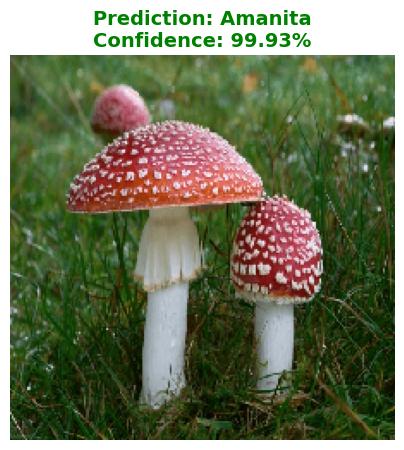


Top 3 Runner-up Guesses:
 - Amanita: 99.9%
 - Russula: 0.0%
 - Hygrocybe: 0.0%


In [ ]:
# ==============================================================================
# CELL 2: UPLOAD IMAGE AND TEST
# ==============================================================================
print("\n🍄 --- PLEASE UPLOAD A MUSHROOM IMAGE TO TEST --- 🍄")

# This will prompt you to upload an image from your local computer
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\nProcessing {filename}...")

    # Load and resize the image to (224, 224) - matching your Optimized Model's input shape
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # Create a batch dimension, as the model expects arrays of shape (batch, height, width, channels)
    img_batch = tf.expand_dims(img_array, 0)

    # Make Prediction
    predictions = test_model.predict(img_batch, verbose=0)
    prediction_scores = predictions[0]

    # Determine the highest confidence class
    winning_index = np.argmax(prediction_scores)
    winning_class = saved_classes[winning_index]
    confidence_percentage = prediction_scores[winning_index] * 100

    # Display the result to the screen
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {winning_class}\nConfidence: {confidence_percentage:.2f}%",
              fontsize=14, fontweight='bold', color='green')
    plt.show()

    # Log the top 3 highest probabilities
    print("\nTop 3 Runner-up Guesses:")
    top_3_indices = np.argsort(prediction_scores)[-3:][::-1]
    for i in top_3_indices:
        print(f" - {saved_classes[i]}: {prediction_scores[i]*100:.1f}%")


!